# Lab02 - Markov Decision Process and Dynamic Programming

**Họ tên:** Tran The Anh  
**MSSV:** 24100707  
**Lớp:** EEE.AI-24106.1  
**Học phần:** Reinforcement Learning

## Mục tiêu

- Tìm hiểu Markov Chain và Markov Decision Process.
- Tính Return và Discounted Return.
- Tìm hiểu State-Value Function và Action-Value Function.
- Thực hiện Bellman Backup.
- Cài đặt Policy Evaluation.
- Cài đặt Policy Improvement.
- Cài đặt Policy Iteration.
- Cài đặt Value Iteration.
- Giải bài toán FrozenLake bằng Dynamic Programming.
- Đánh giá và so sánh Value Iteration với Policy Iteration.

In [3]:
import sys
import os
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))

from mdp_utils import (
    q_from_v,
    policy_evaluation,
    greedy_policy_from_value,
    policy_iteration,
    value_iteration,
    evaluate_policy_by_simulation,
    print_frozenlake_policy
)

print("Current folder:", os.getcwd())
print("NumPy:", np.__version__)
print("Gymnasium:", gym.__version__)
print("mdp_utils: OK")

Current folder: d:\EEE.AI\Học tăng cường cơ bản (TA)\Thực hành\RL_24100707_TranTheAnh\Lab02\notebooks
NumPy: 2.5.2
Gymnasium: 1.3.0
mdp_utils: OK


Transition matrix P:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]

Row sums:
[1. 1. 1.]

Valid matrix: True

State distributions:
t=1: [0.7 0.2 0.1]
t=2: [0.57 0.25 0.18]
t=5: [0.46848 0.2794  0.25212]
t=10: [0.45680544 0.28253268 0.26066188]
t=50: [0.45652174 0.2826087  0.26086957]

30-step simulation:
[0, 1, 1, 2, 2, 0, 2, 2, 2, 0, 0, 0, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 1, 2, 2, 2, 0, 0, 0, 0, 0]

Simulation frequencies: [0.45612 0.28164 0.26224]
Theoretical distribution at t=50: [0.45652174 0.2826087  0.26086957]


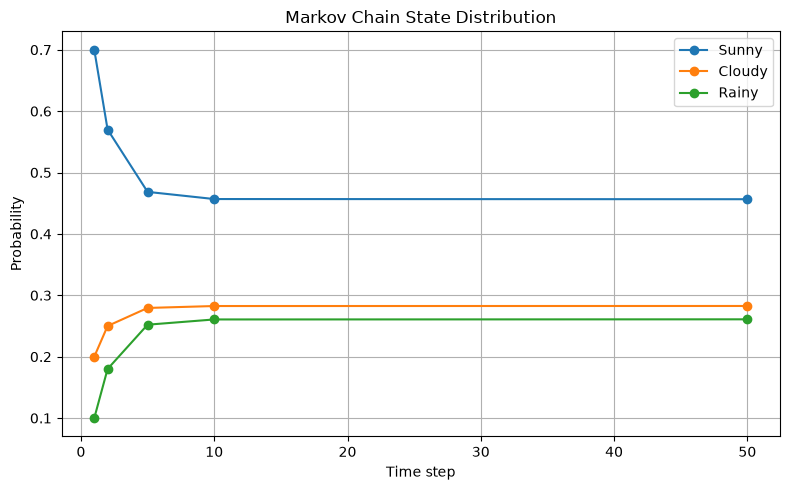

In [6]:
P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.4, 0.3],
    [0.2, 0.3, 0.5]
])

print("Transition matrix P:")
print(P)

print("\nRow sums:")
print(P.sum(axis=1))

def validate_transition_matrix(P, tol=1e-10):
    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        return False
    if np.any(P < 0) or np.any(P > 1):
        return False
    return np.allclose(P.sum(axis=1), 1.0, atol=tol)

print("\nValid matrix:", validate_transition_matrix(P))

p0 = np.array([1.0, 0.0, 0.0])

def state_distribution(p0, P, n_steps):
    p = p0.copy()
    for _ in range(n_steps):
        p = p @ P
    return p

print("\nState distributions:")
for t in [1, 2, 5, 10, 50]:
    print(f"t={t}:", state_distribution(p0, P, t))

def sample_next_state(current_state, P, rng):
    return rng.choice(len(P), p=P[current_state])

rng = np.random.default_rng(42)
state = 0
chain = [state]

for _ in range(30):
    state = sample_next_state(state, P, rng)
    chain.append(state)

print("\n30-step simulation:")
print(chain)

n_simulations = 100000
state = 0
counts = np.zeros(3, dtype=int)

for _ in range(n_simulations):
    state = sample_next_state(state, P, rng)
    counts[state] += 1

frequencies = counts / n_simulations
theoretical = state_distribution(p0, P, 50)

print("\nSimulation frequencies:", frequencies)
print("Theoretical distribution at t=50:", theoretical)

times = [1, 2, 5, 10, 50]
distributions = np.array([state_distribution(p0, P, t) for t in times])

plt.figure(figsize=(8, 5))
for i, name in enumerate(["Sunny", "Cloudy", "Rainy"]):
    plt.plot(times, distributions[:, i], marker="o", label=name)
plt.xlabel("Time step")
plt.ylabel("Probability")
plt.title("Markov Chain State Distribution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../figures/markov_distribution.png", dpi=300)
plt.show()

Returns:
Gamma=0.00: Return=1.000000
Gamma=0.50: Return=1.937500
Gamma=0.90: Return=4.095100
Gamma=0.99: Return=4.900995
Gamma=1.00: Return=5.000000

Discounted returns:
[0.729 0.81  0.9   1.   ]


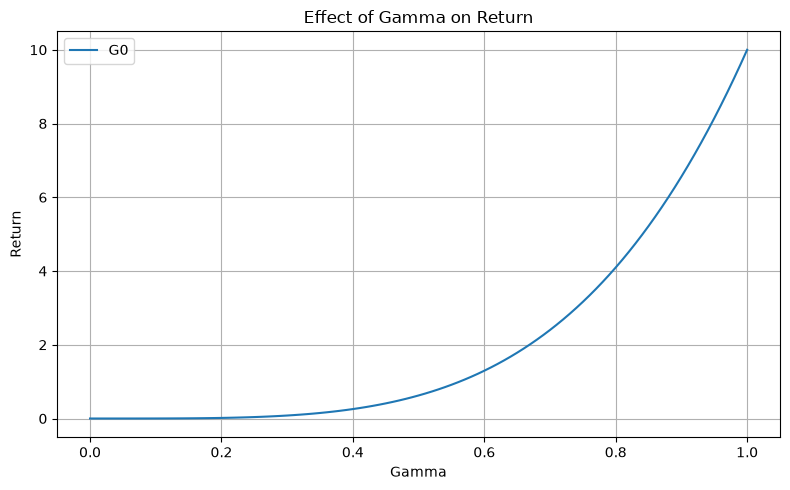


Gamma values where B > A:
0.85 to 1.00


In [7]:
rewards = [1, 1, 1, 1, 1]

def compute_return(rewards, gamma):
    return sum((gamma ** t) * reward for t, reward in enumerate(rewards))

print("Returns:")
for gamma in [0.0, 0.5, 0.9, 0.99, 1.0]:
    print(f"Gamma={gamma:.2f}: Return={compute_return(rewards, gamma):.6f}")

def discounted_returns(rewards, gamma):
    returns = np.zeros(len(rewards))
    G = 0.0
    for t in range(len(rewards) - 1, -1, -1):
        G = rewards[t] + gamma * G
        returns[t] = G
    return returns

print("\nDiscounted returns:")
print(discounted_returns([0, 0, 0, 1], 0.9))

rewards_gamma = [0, 0, 0, 0, 10]
gammas = np.linspace(0, 1, 101)
returns_gamma = [compute_return(rewards_gamma, g) for g in gammas]

plt.figure(figsize=(8, 5))
plt.plot(gammas, returns_gamma, label="G0")
plt.xlabel("Gamma")
plt.ylabel("Return")
plt.title("Effect of Gamma on Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../figures/gamma_comparison.png", dpi=300)
plt.show()

sequence_A = [5, 0, 0, 0, 0]
sequence_B = [0, 0, 0, 0, 10]

better_gammas = [
    g for g in gammas
    if compute_return(sequence_B, g) > compute_return(sequence_A, g)
]

print("\nGamma values where B > A:")
print(f"{min(better_gammas):.2f} to {max(better_gammas):.2f}")

In [8]:
mdp_P = {
    0: {
        0: [(1.0, 1, 1, False)],
        1: [(1.0, 0, 0, False)]
    },
    1: {
        0: [(1.0, 1, 2, True)],
        1: [(1.0, 0, 0, False)]
    }
}

def validate_mdp(P, n_states, n_actions):
    for state in range(n_states):
        for action in range(n_actions):
            transitions = P[state][action]
            total = sum(t[0] for t in transitions)
            if not np.isclose(total, 1.0):
                print(f"Invalid transition at state={state}, action={action}")
                return False
    return True

print("MDP valid:", validate_mdp(mdp_P, 2, 2))

deterministic_policy = np.array([0, 1])

def print_policy(policy):
    print("Deterministic policy:", policy)

print_policy(deterministic_policy)

n_states = 2
n_actions = 2
stochastic_policy = np.ones((n_states, n_actions)) / n_actions

print("\nStochastic policy:")
print(stochastic_policy)

print("\nAction probability sums:")
print(stochastic_policy.sum(axis=1))

MDP valid: True
Deterministic policy: [0 1]

Stochastic policy:
[[0.5 0.5]
 [0.5 0.5]]

Action probability sums:
[1. 1.]


In [9]:
env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True
)

P_fl = env.unwrapped.P

state, _ = env.reset(seed=42)

print("FrozenLake-v1")
print("States:", env.observation_space.n)
print("Actions:", env.action_space.n)
print("Initial observation:", state)

ACTION_NAMES = {
    0: "LEFT",
    1: "DOWN",
    2: "RIGHT",
    3: "UP"
}

print("\nTransitions of state 0:")
for action in range(env.action_space.n):
    print(f"\nAction {action} - {ACTION_NAMES[action]}")
    for probability, next_state, reward, terminated in P_fl[0][action]:
        print(
            f"Probability={probability:.4f}, "
            f"Next state={next_state}, "
            f"Reward={reward}, "
            f"Terminated={terminated}"
        )

def describe_state(env, state):
    print(f"\nState {state}")
    for action in range(env.action_space.n):
        print(f"  Action {action} - {ACTION_NAMES[action]}")
        for transition in env.unwrapped.P[state][action]:
            print("   ", transition)

for state in [0, 1, 14]:
    describe_state(env, state)

valid = True

for state in range(env.observation_space.n):
    for action in range(env.action_space.n):
        total = sum(t[0] for t in P_fl[state][action])
        if not np.isclose(total, 1.0):
            valid = False

print("\nAll transition probabilities valid:", valid)

env_deterministic = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=False
)

print("\nState 0 - RIGHT - deterministic:")
print(env_deterministic.unwrapped.P[0][2])

print("\nState 0 - RIGHT - stochastic:")
print(env.unwrapped.P[0][2])

FrozenLake-v1
States: 16
Actions: 4
Initial observation: 0

Transitions of state 0:

Action 0 - LEFT
Probability=0.3333, Next state=0, Reward=0, Terminated=False
Probability=0.3333, Next state=0, Reward=0, Terminated=False
Probability=0.3333, Next state=4, Reward=0, Terminated=False

Action 1 - DOWN
Probability=0.3333, Next state=0, Reward=0, Terminated=False
Probability=0.3333, Next state=4, Reward=0, Terminated=False
Probability=0.3333, Next state=1, Reward=0, Terminated=False

Action 2 - RIGHT
Probability=0.3333, Next state=4, Reward=0, Terminated=False
Probability=0.3333, Next state=1, Reward=0, Terminated=False
Probability=0.3333, Next state=0, Reward=0, Terminated=False

Action 3 - UP
Probability=0.3333, Next state=1, Reward=0, Terminated=False
Probability=0.3333, Next state=0, Reward=0, Terminated=False
Probability=0.3333, Next state=0, Reward=0, Terminated=False

State 0
  Action 0 - LEFT
    (0.33333333333333337, 0, 0, False)
    (0.3333333333333333, 0, 0, False)
    (0.333333

In [10]:
V = np.zeros(env.observation_space.n)
gamma = 0.99

print("Q-values of state 0:")

for action in range(env.action_space.n):
    q = q_from_v(env, V, 0, action, gamma)
    print(f"Action {action} ({ACTION_NAMES[action]}): {q}")

def action_values(env, V, state, gamma):
    return np.array([
        q_from_v(env, V, state, action, gamma)
        for action in range(env.action_space.n)
    ])

print("\nAll Q-values of state 0:")
print(action_values(env, V, 0, gamma))

random_policy = np.ones(
    (env.observation_space.n, env.action_space.n)
) / env.action_space.n

V_random, n_iterations = policy_evaluation(
    env,
    random_policy,
    gamma=0.99,
    theta=1e-8,
    max_iterations=10000
)

print("\nPolicy Evaluation")
print("Iterations:", n_iterations)
print("Value table:")
print(V_random)

print("\nState 0 Q-values after evaluation:")
print(action_values(env, V_random, 0, gamma))

Q-values of state 0:
Action 0 (LEFT): 0.0
Action 1 (DOWN): 0.0
Action 2 (RIGHT): 0.0
Action 3 (UP): 0.0

All Q-values of state 0:
[0. 0. 0. 0.]

Policy Evaluation
Iterations: 71
Value table:
[0.0123561  0.01042443 0.01933841 0.00947773 0.01478703 0.
 0.03889444 0.         0.03260246 0.08433763 0.13781085 0.
 0.         0.17034482 0.43357944 0.        ]

State 0 Q-values after evaluation:
[0.01303475 0.0123973  0.0123973  0.01159509]


In [11]:
greedy_policy = greedy_policy_from_value(env, V_random, gamma)

print("Greedy policy:")
print_frozenlake_policy(env, greedy_policy)

old_policy = np.zeros(env.observation_space.n, dtype=int)
new_policy = greedy_policy_from_value(env, V_random, gamma)

changed_states = np.sum(old_policy != new_policy)

print("\nPolicy improvement:")
print("Changed states:", changed_states)

pi_policy, pi_V, pi_iterations = policy_iteration(
    env,
    gamma=0.99,
    theta=1e-8,
    max_iterations=1000
)

print("\nPolicy Iteration")
print("Iterations:", pi_iterations)
print("Value table:")
print(pi_V)

print("\nPolicy:")
print_frozenlake_policy(env, pi_policy)

policy_stable = np.array_equal(
    pi_policy,
    greedy_policy_from_value(env, pi_V, gamma)
)

print("\nPolicy stable:", policy_stable)
print(f"Policy Iteration converged after {pi_iterations} iterations.")

Greedy policy:
← ↑ ← ↑
← H ← H
↑ ↓ ← H
H → ↓ G

Policy improvement:
Changed states: 6

Policy Iteration
Iterations: 7
Value table:
[0.54202577 0.49880297 0.47069543 0.45685142 0.55845081 0.
 0.35834796 0.         0.59179862 0.64307973 0.61520747 0.
 0.         0.74172037 0.86283739 0.        ]

Policy:
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G

Policy stable: True
Policy Iteration converged after 7 iterations.


Value Iteration
Iterations: 438

Optimal state values:
[0.54202577 0.49880297 0.47069543 0.45685142 0.55845081 0.
 0.35834796 0.         0.59179862 0.64307973 0.61520747 0.
 0.         0.74172037 0.86283739 0.        ]

Optimal policy:
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


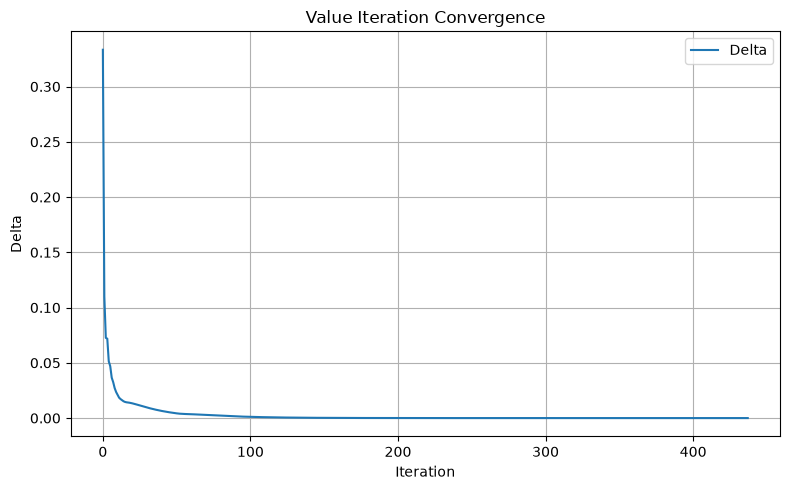


Final delta: 9.771440878658666e-09


In [12]:
vi_V, vi_iterations, vi_deltas = value_iteration(
    env,
    gamma=0.99,
    theta=1e-8,
    max_iterations=10000
)

vi_policy = greedy_policy_from_value(
    env,
    vi_V,
    gamma=0.99
)

print("Value Iteration")
print("Iterations:", vi_iterations)

print("\nOptimal state values:")
print(vi_V)

print("\nOptimal policy:")
print_frozenlake_policy(env, vi_policy)

plt.figure(figsize=(8, 5))
plt.plot(vi_deltas, label="Delta")
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.title("Value Iteration Convergence")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../figures/value_iteration_convergence.png", dpi=300)
plt.show()

print("\nFinal delta:", vi_deltas[-1])

In [13]:
random_deterministic_policy = np.random.default_rng(42).integers(
    0,
    env.action_space.n,
    size=env.observation_space.n
)

random_result = evaluate_policy_by_simulation(
    env,
    random_deterministic_policy,
    n_episodes=1000,
    seed=42
)

vi_result = evaluate_policy_by_simulation(
    env,
    vi_policy,
    n_episodes=1000,
    seed=42
)

pi_result = evaluate_policy_by_simulation(
    env,
    pi_policy,
    n_episodes=1000,
    seed=42
)

print(f"{'Policy':<20}{'Success':<15}{'Mean Reward':<15}{'Mean Length':<15}")
print("-" * 65)

print(
    f"{'Random':<20}"
    f"{random_result['success_rate']:<15.4f}"
    f"{random_result['mean_reward']:<15.4f}"
    f"{random_result['mean_length']:<15.3f}"
)

print(
    f"{'Value Iteration':<20}"
    f"{vi_result['success_rate']:<15.4f}"
    f"{vi_result['mean_reward']:<15.4f}"
    f"{vi_result['mean_length']:<15.3f}"
)

print(
    f"{'Policy Iteration':<20}"
    f"{pi_result['success_rate']:<15.4f}"
    f"{pi_result['mean_reward']:<15.4f}"
    f"{pi_result['mean_length']:<15.3f}"
)

print("\nVI:")
print(vi_result)

print("\nPI:")
print(pi_result)

Policy              Success        Mean Reward    Mean Length    
-----------------------------------------------------------------
Random              0.0000         0.0000         6.026          
Value Iteration     0.7520         0.7520         44.319         
Policy Iteration    0.7520         0.7520         44.319         

VI:
{'success_rate': 0.752, 'mean_reward': np.float64(0.752), 'mean_length': np.float64(44.319), 'min_length': np.int64(6), 'max_length': np.int64(100)}

PI:
{'success_rate': 0.752, 'mean_reward': np.float64(0.752), 'mean_length': np.float64(44.319), 'min_length': np.int64(6), 'max_length': np.int64(100)}


Algorithm           Iterations  Time(s)     Success Rate   Mean Reward    
--------------------------------------------------------------------------
Value Iteration     438         0.054772    0.7520         0.7520         
Policy Iteration    7           0.034780    0.7520         0.7520         


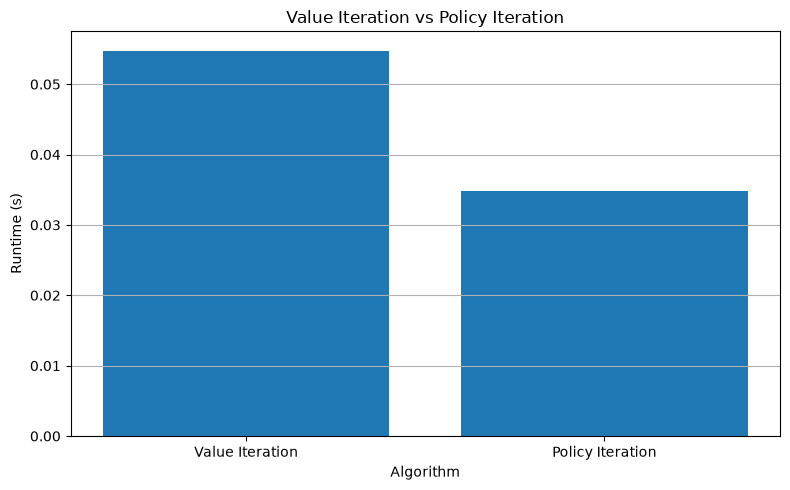

In [15]:
from time import perf_counter

start = perf_counter()

vi_V, vi_iterations, vi_deltas = value_iteration(
    env,
    gamma=0.99,
    theta=1e-8,
    max_iterations=10000
)

vi_time = perf_counter() - start
vi_policy = greedy_policy_from_value(env, vi_V, 0.99)

start = perf_counter()

pi_policy, pi_V, pi_iterations = policy_iteration(
    env,
    gamma=0.99,
    theta=1e-8,
    max_iterations=1000
)

pi_time = perf_counter() - start

vi_result = evaluate_policy_by_simulation(
    env, vi_policy, n_episodes=1000, seed=42
)

pi_result = evaluate_policy_by_simulation(
    env, pi_policy, n_episodes=1000, seed=42
)

print(
    f"{'Algorithm':<20}"
    f"{'Iterations':<12}"
    f"{'Time(s)':<12}"
    f"{'Success Rate':<15}"
    f"{'Mean Reward':<15}"
)

print("-" * 74)

print(
    f"{'Value Iteration':<20}"
    f"{vi_iterations:<12}"
    f"{vi_time:<12.6f}"
    f"{vi_result['success_rate']:<15.4f}"
    f"{vi_result['mean_reward']:<15.4f}"
)

print(
    f"{'Policy Iteration':<20}"
    f"{pi_iterations:<12}"
    f"{pi_time:<12.6f}"
    f"{pi_result['success_rate']:<15.4f}"
    f"{pi_result['mean_reward']:<15.4f}"
)

algorithms = ["Value Iteration", "Policy Iteration"]
times = [vi_time, pi_time]

plt.figure(figsize=(8, 5))
plt.bar(algorithms, times)
plt.xlabel("Algorithm")
plt.ylabel("Runtime (s)")
plt.title("Value Iteration vs Policy Iteration")
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("../figures/algorithm_comparison.png", dpi=300)
plt.show()

In [16]:
from main import main

print("=" * 60)
print("MINI-PROJECT - FrozenLake slippery=False")
print("=" * 60)

main(
    is_slippery=False,
    gamma=0.99,
    theta=1e-8,
    max_iterations=10000
)

print("\n" + "=" * 60)
print("MINI-PROJECT - FrozenLake slippery=True")
print("=" * 60)

main(
    is_slippery=True,
    gamma=0.99,
    theta=1e-8,
    max_iterations=10000
)

MINI-PROJECT - FrozenLake slippery=False
=== ENVIRONMENT ===
FrozenLake-v1 4x4
Slippery: False
States: 16
Actions: 4
Transition model: 16

=== VALUE ITERATION ===
Value table:
[0.95099005 0.96059601 0.970299   0.96059601 0.96059601 0.
 0.9801     0.         0.970299   0.9801     0.99       0.
 0.         0.99       1.         0.        ]
Policy:
↓ → ↓ ←
↓ H ↓ H
→ ↓ ↓ H
H → → G
Iterations: 7
Runtime: 0.0007586000001538196
Success rate: 1.0
Mean reward: 1.0
Mean episode length: 6.0

=== POLICY ITERATION ===
Value table:
[0.95099005 0.96059601 0.970299   0.96059601 0.96059601 0.
 0.9801     0.         0.970299   0.9801     0.99       0.
 0.         0.99       1.         0.        ]
Policy:
↓ → ↓ ←
↓ H ↓ H
→ ↓ ↓ H
H → → G
Iterations: 7
Runtime: 0.0013664999996763072
Success rate: 1.0
Mean reward: 1.0
Mean episode length: 6.0

=== COMPARISON ===
Algorithm           Iterations  Runtime        Success Rate   Mean Reward    
---------------------------------------------------------------------

## Kết luận

Qua Lab02, em đã tìm hiểu và thực hành các khái niệm Markov Chain, Markov Decision Process, Transition Probability, Return, Discount Factor, Policy, State-Value Function và Action-Value Function.

Các thuật toán Dynamic Programming gồm Policy Evaluation, Policy Improvement, Policy Iteration và Value Iteration đã được cài đặt và áp dụng trên môi trường FrozenLake-v1.

Kết quả cho thấy Value Iteration và Policy Iteration đều có thể tìm được policy tốt cho FrozenLake. Với môi trường `slippery=False`, agent đạt success rate 1.0. Với `slippery=True`, do transition mang tính ngẫu nhiên nên success rate giảm xuống khoảng 0.752.

Policy Iteration hội tụ với số vòng lặp ít hơn Value Iteration trong thí nghiệm. Tuy nhiên, hiệu quả runtime phụ thuộc vào cách cài đặt và cấu hình môi trường.

Qua bài thực hành, em hiểu được mối quan hệ giữa transition model, Bellman equation, value function và optimal policy trong Dynamic Programming.